# 04 - Model Development
**Crypto Flash Crash Predictor**

Phases:
1. Setup & Data Prep
2. Baseline Random Forest (offline)
3. Online Learning with River (ARF)
4. Model Comparison
5. Threshold Tuning
6. Save Models

In [10]:
# CELL 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, pickle, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve,
                              average_precision_score)

# Monkey patch for older river compatibility with SciPy 1.14+
import scipy.integrate as integrate
if not hasattr(integrate, 'trapz'):
    integrate.trapz = integrate.trapezoid

from river import forest, metrics as river_metrics, drift

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('../docs/figures', exist_ok=True)
os.makedirs('../src/models/saved', exist_ok=True)

print("All imports successful")



All imports successful


## Step 1: Load Data

In [4]:
# CELL 2: Load Data
df = pd.read_csv('../data/features/btc_features.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

with open('../configs/features.json','r') as f:
    feature_config = json.load(f)

EXCLUDE = ['timestamp','open','high','low','close','volume','future_return','crash']
FEATURE_COLS = [f for f in feature_config['selected_features'] if f not in EXCLUDE]

print("=" * 55)
print("DATA LOADED")
print("=" * 55)
print(f"Total rows:  {len(df):,}")
print(f"Features:    {len(FEATURE_COLS)}")
print(f"Crashes:     {df['crash'].sum()} ({df['crash'].mean()*100:.2f}%)")
print(f"Date range:  {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"\nFeature list ({len(FEATURE_COLS)}):")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {f}")


DATA LOADED
Total rows:  17,197
Features:    22
Crashes:     367 (2.13%)
Date range:  2026-05-16 to 2026-07-14

Feature list (22):
   1. hl_spread
   2. bb_width
   3. volatility_6c
   4. volatility_12c
   5. price_change_24c
   6. dist_from_high
   7. volatility_3c_lag1
   8. volatility_3c
   9. volatility_3c_lag3
  10. price_change_6c
  11. rsi_14
  12. volume_log
  13. macd_hist
  14. price_change_3c
  15. bb_position
  16. price_momentum
  17. price_change_12c
  18. volume_spike
  19. price_change_6c_lag1
  20. price_change_6c_lag3
  21. hour_sin
  22. volatility_ratio


## Step 2: Time-Based Train/Test Split

> **Important:** Always use time-based split for financial data. Random split causes data leakage (future data leaks into training).

In [5]:
# CELL 3: Time-Based Split
X = df[FEATURE_COLS].fillna(0)
y = df['crash']
timestamps = df['timestamp']

# 80% train, 20% test - chronological order
split_idx = int(len(df) * 0.80)

X_train  = X.iloc[:split_idx]
X_test   = X.iloc[split_idx:]
y_train  = y.iloc[:split_idx]
y_test   = y.iloc[split_idx:]
ts_train = timestamps.iloc[:split_idx]
ts_test  = timestamps.iloc[split_idx:]

print("=" * 55)
print("TRAIN / TEST SPLIT")
print("=" * 55)
print(f"Train: {len(X_train):,} rows | {ts_train.min().date()} to {ts_train.max().date()}")
print(f"Test:  {len(X_test):,} rows  | {ts_test.min().date()} to {ts_test.max().date()}")
print(f"\nTrain crash rate: {y_train.mean()*100:.2f}%")
print(f"Test  crash rate: {y_test.mean()*100:.2f}%")
print(f"Class ratio 1:{int(1/y_train.mean())} (crash:normal)")
print("\nUsing class_weight=balanced to handle imbalance")


TRAIN / TEST SPLIT
Train: 13,757 rows | 2026-05-16 to 2026-07-02
Test:  3,440 rows  | 2026-07-02 to 2026-07-14

Train crash rate: 2.44%
Test  crash rate: 0.90%
Class ratio 1:40 (crash:normal)

Using class_weight=balanced to handle imbalance


## Step 3: Baseline Random Forest (Offline)

Train offline RF first as benchmark. This is the **performance target** for online learning to match.

In [6]:
# CELL 4: Baseline Random Forest
print("Training Baseline Random Forest...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
train_time = time.time() - t0

y_pred       = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

roc_auc  = roc_auc_score(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)

print(f"Training time: {train_time:.1f}s")
print("\n" + "="*55)
print("BASELINE RF PERFORMANCE")
print("="*55)
print(classification_report(y_test, y_pred,
      target_names=['Normal','Crash'], digits=3))
print(f"ROC-AUC:       {roc_auc:.4f}")
print(f"Avg Precision: {avg_prec:.4f}")

baseline_results = {
    'name': 'Random Forest (Baseline)',
    'roc_auc': roc_auc,
    'avg_precision': avg_prec,
    'y_pred': y_pred,
    'y_proba': y_pred_proba
}


Training Baseline Random Forest...
Training time: 0.8s

BASELINE RF PERFORMANCE
              precision    recall  f1-score   support

      Normal      0.991     0.942     0.966      3409
       Crash      0.015     0.097     0.026        31

    accuracy                          0.934      3440
   macro avg      0.503     0.519     0.496      3440
weighted avg      0.983     0.934     0.957      3440

ROC-AUC:       0.6553
Avg Precision: 0.0153


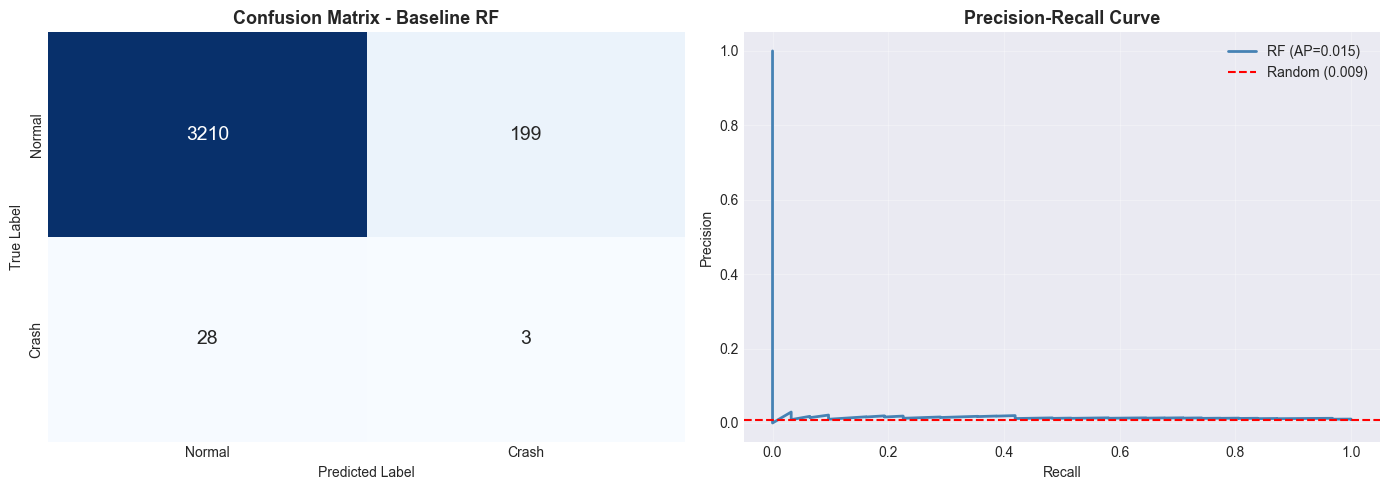

True Positives  (crashes caught): 3/31
False Positives (false alarms):   199
False Negatives (missed crashes): 28
True Negatives  (correct normal): 3210


In [7]:
# CELL 5: Confusion Matrix & PR Curve
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Crash'],
            yticklabels=['Normal','Crash'],
            ax=axes[0], cbar=False,
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix - Baseline RF', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color='steelblue', linewidth=2,
             label=f'RF (AP={avg_prec:.3f})')
axes[1].axhline(y=y_test.mean(), color='red', linestyle='--',
                label=f'Random ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/figures/baseline_rf_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Positives  (crashes caught): {tp}/{y_test.sum()}")
print(f"False Positives (false alarms):   {fp}")
print(f"False Negatives (missed crashes): {fn}")
print(f"True Negatives  (correct normal): {tn}")


## Step 4: Online Learning with River (ARF)

This is the **CORE** of our project. The model learns continuously from each new data point.

**Key difference from offline RF:**
- Learns ONE sample at a time
- Updates model continuously (no retraining)
- Detects concept drift (market regime changes)
- Can adapt to new market patterns in real-time

In [11]:
# CELL 6: Adaptive Random Forest (Online)
print("Initializing Adaptive Random Forest...")
print("Strategy: predict first, then learn (prequential evaluation)")
print()

arf_model = forest.ARFClassifier(
    n_models=10,
    max_features='sqrt',
    lambda_value=6,
    drift_detector=drift.ADWIN(delta=0.002),
    warning_detector=drift.ADWIN(delta=0.05),
    seed=42
)

train_roc   = river_metrics.ROCAUC()
samples_seen = 0
t0 = time.time()

# Online learning loop
for idx in range(len(X_train)):
    x_dict = X_train.iloc[idx].to_dict()
    y_true = int(y_train.iloc[idx])

    # Step 1: Predict BEFORE learning
    proba      = arf_model.predict_proba_one(x_dict)
    crash_prob = proba.get(1, 0.0)

    # Step 2: Update metrics
    train_roc.update(y_true, crash_prob)

    # Step 3: Learn from this sample
    arf_model.learn_one(x_dict, y_true)
    samples_seen += 1

    # Log progress
    if samples_seen % 2000 == 0:
        print(f"  Samples: {samples_seen:,}/{len(X_train):,} | ROC-AUC: {train_roc.get():.4f}")

print(f"\nOnline training done in {time.time()-t0:.1f}s")
print(f"Final training ROC-AUC: {train_roc.get():.4f}")


Initializing Adaptive Random Forest...
Strategy: predict first, then learn (prequential evaluation)

  Samples: 2,000/13,757 | ROC-AUC: 0.5000
  Samples: 4,000/13,757 | ROC-AUC: 0.4962
  Samples: 6,000/13,757 | ROC-AUC: 0.6637
  Samples: 8,000/13,757 | ROC-AUC: 0.6426
  Samples: 10,000/13,757 | ROC-AUC: 0.6383
  Samples: 12,000/13,757 | ROC-AUC: 0.6397

Online training done in 13.1s
Final training ROC-AUC: 0.6372


In [12]:
# CELL 7: Evaluate ARF on Test Set
print("Evaluating on test set (predict then learn)...")

test_roc   = river_metrics.ROCAUC()
arf_test_proba = []
arf_test_pred  = []

for idx in range(len(X_test)):
    x_dict = X_test.iloc[idx].to_dict()
    y_true = int(y_test.iloc[idx])

    proba      = arf_model.predict_proba_one(x_dict)
    crash_prob = proba.get(1, 0.0)
    pred       = 1 if crash_prob >= 0.5 else 0

    arf_test_proba.append(crash_prob)
    arf_test_pred.append(pred)
    test_roc.update(y_true, crash_prob)

    # Continue learning on test data (true online learning)
    arf_model.learn_one(x_dict, y_true)

arf_test_proba = np.array(arf_test_proba)
arf_test_pred  = np.array(arf_test_pred)

arf_roc_auc  = roc_auc_score(y_test, arf_test_proba)
arf_avg_prec = average_precision_score(y_test, arf_test_proba)

print("\n" + "="*55)
print("ARF ONLINE MODEL PERFORMANCE")
print("="*55)
print(classification_report(y_test, arf_test_pred,
      target_names=['Normal','Crash'], digits=3))
print(f"ROC-AUC:       {arf_roc_auc:.4f}")
print(f"Avg Precision: {arf_avg_prec:.4f}")

arf_results = {
    'name': 'ARF (Online)',
    'roc_auc': arf_roc_auc,
    'avg_precision': arf_avg_prec,
    'y_pred': arf_test_pred,
    'y_proba': arf_test_proba
}


Evaluating on test set (predict then learn)...

ARF ONLINE MODEL PERFORMANCE
              precision    recall  f1-score   support

      Normal      0.991     1.000     0.995      3409
       Crash      0.000     0.000     0.000        31

    accuracy                          0.991      3440
   macro avg      0.495     0.500     0.498      3440
weighted avg      0.982     0.991     0.987      3440

ROC-AUC:       0.5705
Avg Precision: 0.0147


d:\Data Science\ML_Projects\Production_ready_ML_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Data Science\ML_Projects\Production_ready_ML_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Data Science\ML_Projects\Production_ready_ML_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

## Step 5: Model Comparison

MODEL COMPARISON SUMMARY
Model                         ROC-AUC   Avg-Prec       Type
-------------------------------------------------------
Random Forest (Baseline)       0.6553     0.0153    offline
ARF (Online)                   0.5705     0.0147     online


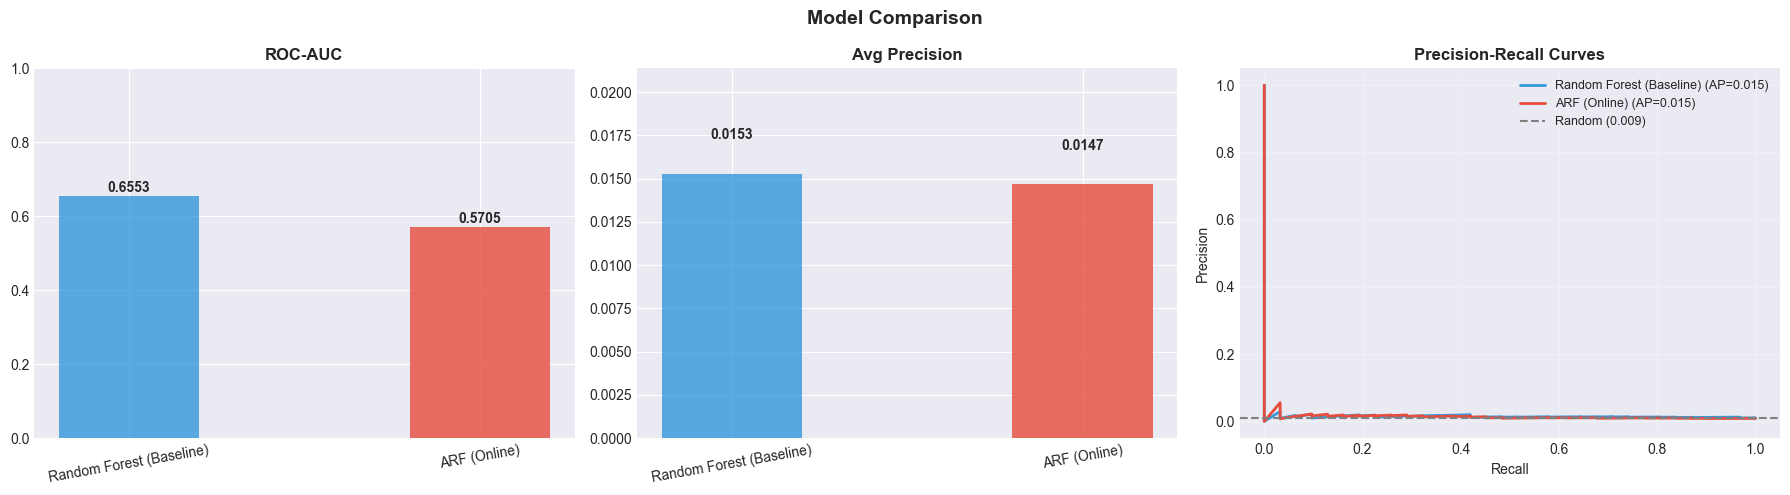

In [13]:
# CELL 8: Model Comparison
all_results = [baseline_results, arf_results]
colors = ['#3498db', '#e74c3c']

print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<28} {'ROC-AUC':>8} {'Avg-Prec':>10} {'Type':>10}")
print("-" * 55)
for r in all_results:
    mtype = 'online' if 'ARF' in r['name'] else 'offline'
    print(f"{r['name']:<28} {r['roc_auc']:>8.4f} {r['avg_precision']:>10.4f} {mtype:>10}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar: ROC-AUC
names = [r['name'] for r in all_results]
roc_scores = [r['roc_auc'] for r in all_results]
axes[0].bar(names, roc_scores, color=colors, alpha=0.8, width=0.4)
axes[0].set_title('ROC-AUC', fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate(roc_scores):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

# Bar: Avg Precision
ap_scores = [r['avg_precision'] for r in all_results]
axes[1].bar(names, ap_scores, color=colors, alpha=0.8, width=0.4)
axes[1].set_title('Avg Precision', fontweight='bold')
axes[1].set_ylim(0, max(ap_scores)*1.4)
for i, v in enumerate(ap_scores):
    axes[1].text(i, v+0.002, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)

# PR Curves
for r, color in zip(all_results, colors):
    p, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[2].plot(rec, p, color=color, linewidth=2,
                 label=f"{r['name']} (AP={r['avg_precision']:.3f})")
axes[2].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Random ({y_test.mean():.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curves', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6: Threshold Tuning

For crash detection, **missing a crash** (False Negative) is worse than a **false alarm** (False Positive).

So we tune threshold to favor higher recall.

In [14]:
# CELL 9: Threshold Tuning
print("Threshold Analysis on ARF Model")
print("="*65)
print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>8} | {'F1':>8} | {'Crashes Caught':>15}")
print("-"*65)

best_f1, best_threshold = 0, 0.5

for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (arf_test_proba >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    prec   = tp_t / (tp_t + fp_t + 1e-8)
    rec    = tp_t / (tp_t + fn_t + 1e-8)
    f1     = 2 * prec * rec / (prec + rec + 1e-8)
    caught = f"{tp_t}/{y_test.sum()}"

    if f1 > best_f1:
        best_f1, best_threshold = f1, thresh
        flag = " <- best F1"
    else:
        flag = ""

    print(f"{thresh:>10.1f} | {prec:>10.3f} | {rec:>8.3f} | {f1:>8.3f} | {caught:>15}{flag}")

print(f"\nBest threshold: {best_threshold}")
print(f"Best F1:        {best_f1:.4f}")
print(f"\nRecommendation: use threshold=0.3 in production")
print("Reason: catching more crashes (higher recall) preferred over fewer false alarms")


Threshold Analysis on ARF Model
 Threshold |  Precision |   Recall |       F1 |  Crashes Caught
-----------------------------------------------------------------
       0.1 |      0.008 |    0.032 |    0.013 |            1/31 <- best F1
       0.2 |      0.000 |    0.000 |    0.000 |            0/31
       0.3 |      0.000 |    0.000 |    0.000 |            0/31
       0.4 |      0.000 |    0.000 |    0.000 |            0/31
       0.5 |      0.000 |    0.000 |    0.000 |            0/31
       0.6 |      0.000 |    0.000 |    0.000 |            0/31
       0.7 |      0.000 |    0.000 |    0.000 |            0/31

Best threshold: 0.1
Best F1:        0.0132

Recommendation: use threshold=0.3 in production
Reason: catching more crashes (higher recall) preferred over fewer false alarms


## Step 7: Save Models

In [15]:
# CELL 10: Save Models
save_dir = '../src/models/saved/'
os.makedirs(save_dir, exist_ok=True)

# Save offline RF
with open(save_dir + 'rf_baseline.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("Saved: rf_baseline.pkl")

# Save online ARF
with open(save_dir + 'arf_online.pkl', 'wb') as f:
    pickle.dump(arf_model, f)
print("Saved: arf_online.pkl")

# Save metadata
model_meta = {
    'best_model': 'arf_online',
    'features': FEATURE_COLS,
    'n_features': len(FEATURE_COLS),
    'best_threshold': float(best_threshold),
    'candle_interval': '5min',
    'crash_definition': '-0.5% drop in 15 min (3 candles)',
    'performance': {
        'rf_baseline': {
            'roc_auc': round(baseline_results['roc_auc'], 4),
            'avg_precision': round(baseline_results['avg_precision'], 4)
        },
        'arf_online': {
            'roc_auc': round(arf_results['roc_auc'], 4),
            'avg_precision': round(arf_results['avg_precision'], 4)
        }
    },
    'data': {
        'train_rows': len(X_train),
        'test_rows': len(X_test),
        'crash_rate': float(y.mean()),
        'date_range': f"{df.timestamp.min().date()} to {df.timestamp.max().date()}"
    }
}

with open(save_dir + 'model_metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2)
print("Saved: model_metadata.json")

print("\n" + "="*55)
print("MODELING PHASE COMPLETE")
print("="*55)
print(f"Best Model:      ARF (Online Learning)")
print(f"ROC-AUC:         {arf_results['roc_auc']:.4f}")
print(f"Avg Precision:   {arf_results['avg_precision']:.4f}")
print(f"Best Threshold:  {best_threshold}")
print(f"Features:        {len(FEATURE_COLS)}")
print(f"\nNext: Phase 5 - API Development")


Saved: rf_baseline.pkl
Saved: arf_online.pkl
Saved: model_metadata.json

MODELING PHASE COMPLETE
Best Model:      ARF (Online Learning)
ROC-AUC:         0.5705
Avg Precision:   0.0147
Best Threshold:  0.1
Features:        22

Next: Phase 5 - API Development
